<a href="https://colab.research.google.com/github/yunussfr/data_analysis/blob/main/DataAnalysis2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files

yuklenen_dosyalar = files.upload()

Saving e_ticaret_islem_verisi.csv to e_ticaret_islem_verisi.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [ ]:
dosya_adi = "e_ticaret_islem_verisi.csv"

df = pd.read_csv(dosya_adi)

print("Veri başarıyla yüklendi.")

Veri başarıyla yüklendi.


df:DataFrame


In [ ]:
df.head()


,siparis_id,musteri_id,siparis_tarihi,sehir,musteri_kidem_ayi,kategori,birim_fiyat,adet,indirim_orani,kampanya,odeme_yontemi,cihaz,kargo_gunu,iade_edildi,memnuniyet_puani,siparis_tutari
0,S001337,M0012,2025-12-26,İstanbul,20,Elektronik,5070.49,3.0,0.00,Yok,Kredi Kartı,Mobil,3.0,Hayır,4.0,15211.47
1,S000257,M0222,2025-06-10,İstanbul,12,Kitap,170.16,3.0,0.15,Hafta Sonu,Banka Kartı,Masaüstü,4.0,Hayır,4.0,433.91
2,S000889,M0116,2025-12-20,Elazığ,21,Kozmetik,256.64,2.0,0.10,Hafta Sonu,Kredi Kartı,Mobil,6.0,Evet,2.0,461.95
3,S001098,M0316,2025-07-06,Elazığ,2,Spor,749.40,1.0,0.15,Sepette İndirim,Kredi Kartı,Mobil,3.0,Hayır,4.0,636.99
4,S000205,M0191,2025-08-17,Bursa,48,Giyim,774.81,1.0,0.10,Hafta Sonu,Banka Kartı,Masaüstü,2.0,Hayır,5.0,697.33


In [ ]:
df.tail()

,siparis_id,musteri_id,siparis_tarihi,sehir,musteri_kidem_ayi,kategori,birim_fiyat,adet,indirim_orani,kampanya,odeme_yontemi,cihaz,kargo_gunu,iade_edildi,memnuniyet_puani,siparis_tutari
1405,S000346,M0309,2025-10-09,İzmir,18,Giyim,429.52,4.0,0.05,Hafta Sonu,Kredi Kartı,Mobil,4.0,Evet,2.0,1632.18
1406,S000579,M0309,2025-09-26,İzmir,18,Giyim,285.11,6.0,0.00,Yok,Kapıda Ödeme,Mobil,3.0,Hayır,4.0,1710.66
1407,S000831,M0163,2025-07-04,Elazığ,38,Kitap,216.89,1.0,0.00,Yok,Banka Kartı,Mobil,4.0,Hayır,4.0,216.89
1408,S000280,M0309,2025-04-22,İzmir,18,Elektronik,6724.67,2.0,0.05,Hafta Sonu,Kredi Kartı,Mobil,1.0,Hayır,4.0,12776.87
1409,S000666,M0179,2025-08-05,İstanbul,5,Elektronik,645.59,2.0,0.20,Özel Gün,Kredi Kartı,Masaüstü,6.0,Hayır,2.0,1032.94


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1410 entries, 0 to 1409
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   siparis_id         1410 non-null   object 
 1   musteri_id         1410 non-null   object 
 2   siparis_tarihi     1410 non-null   object 
 3   sehir              1410 non-null   object 
 4   musteri_kidem_ayi  1410 non-null   int64  
 5   kategori           1410 non-null   object 
 6   birim_fiyat        1410 non-null   float64
 7   adet               1410 non-null   float64
 8   indirim_orani      1400 non-null   float64
 9   kampanya           1410 non-null   object 
 10  odeme_yontemi      1396 non-null   object 
 11  cihaz              1410 non-null   object 
 12  kargo_gunu         1392 non-null   float64
 13  iade_edildi        1410 non-null   object 
 14  memnuniyet_puani   1323 non-null   float64
 15  siparis_tutari     1410 non-null   float64
dtypes: float64(6), int64(1),

In [ ]:
print("Toplam satır sayısı:", len(df))

print(
    "Benzersiz sipariş sayısı:",
    df["siparis_id"].nunique()
)

print(
    "Benzersiz müşteri sayısı:",
    df["musteri_id"].nunique()
)

Toplam satır sayısı: 1410
Benzersiz sipariş sayısı: 1400
Benzersiz müşteri sayısı: 284


In [ ]:
df["siparis_tutari"].mean()

np.float64(2847.2537730496456)

In [ ]:
df["siparis_tarihi_dt"] = pd.to_datetime(
    df["siparis_tarihi"],
    errors="coerce"
)
gecersiz_tarih_sayisi = (
    df["siparis_tarihi_dt"]
    .isna()
    .sum()
)

print(
    "Geçersiz veya eksik tarih sayısı:",
    gecersiz_tarih_sayisi
)

Geçersiz veya eksik tarih sayısı: 1


In [ ]:
df[
    df["siparis_tarihi_dt"].isna()
][
    [
        "siparis_id",
        "siparis_tarihi"
    ]
]

,siparis_id,siparis_tarihi
1168,S000412,2026-02-30


In [25]:
tam_tekrar_sayisi = df.duplicated().sum()

print(
    "Tamamen aynı tekrar eden satır sayısı:",
    tam_tekrar_sayisi
)

Tamamen aynı tekrar eden satır sayısı: 10


In [26]:
df[
    df.duplicated(keep=False)
].sort_values("siparis_id")

,siparis_id,musteri_id,siparis_tarihi,sehir,musteri_kidem_ayi,kategori,birim_fiyat,adet,indirim_orani,kampanya,odeme_yontemi,cihaz,kargo_gunu,iade_edildi,memnuniyet_puani,siparis_tutari,siparis_tarihi_dt
27,S000037,M0309,2025-09-12,İzmir,18,Elektronik,3095.31,1.0,0.00,Yok,Kredi Kartı,Masaüstü,6.0,Hayır,5.0,3095.31,2025-09-12
190,S000037,M0309,2025-09-12,İzmir,18,Elektronik,3095.31,1.0,0.00,Yok,Kredi Kartı,Masaüstü,6.0,Hayır,5.0,3095.31,2025-09-12
1156,S000040,M0293,2025-09-19,İstanbul,31,Giyim,955.24,5.0,0.15,Hafta Sonu,Kredi Kartı,Mobil,1.0,Hayır,5.0,4059.77,2025-09-19
1334,S000040,M0293,2025-09-19,İstanbul,31,Giyim,955.24,5.0,0.15,Hafta Sonu,Kredi Kartı,Mobil,1.0,Hayır,5.0,4059.77,2025-09-19
412,S000166,M0064,2025-04-17,İzmir,40,Giyim,726.84,2.0,0.10,Hafta Sonu,Kredi Kartı,Mobil,2.0,Evet,2.0,1308.31,2025-04-17
309,S000166,M0064,2025-04-17,İzmir,40,Giyim,726.84,2.0,0.10,Hafta Sonu,Kredi Kartı,Mobil,2.0,Evet,2.0,1308.31,2025-04-17
549,S000321,M0309,2025-05-09,İzmir,18,Ev & Yaşam,770.24,1.0,0.15,Sepette İndirim,Banka Kartı,Masaüstü,2.0,Hayır,3.0,654.70,2025-05-09
255,S000321,M0309,2025-05-09,İzmir,18,Ev & Yaşam,770.24,1.0,0.15,Sepette İndirim,Banka Kartı,Masaüstü,2.0,Hayır,3.0,654.70,2025-05-09
476,S000910,M0160,2025-10-02,Ankara,46,Kozmetik,194.90,1.0,0.00,Yok,Kredi Kartı,Mobil,4.0,Hayır,5.0,194.90,2025-10-02
1353,S000910,M0160,2025-10-02,Ankara,46,Kozmetik,194.90,1.0,0.00,Yok,Kredi Kartı,Mobil,4.0,Hayır,5.0,194.90,2025-10-02


In [28]:
eksik_deger_ozeti = pd.DataFrame({
    "eksik_deger_sayisi": df.isna().sum(),
    "eksik_deger_orani_yuzde": (
        df.isna().mean() * 100
    ).round(2)
})

eksik_deger_ozeti = (
    eksik_deger_ozeti
    .sort_values(
        "eksik_deger_sayisi",
        ascending=False
    )
)

eksik_deger_ozeti

,eksik_deger_sayisi,eksik_deger_orani_yuzde
memnuniyet_puani,87,6.17
kargo_gunu,18,1.28
odeme_yontemi,14,0.99
indirim_orani,10,0.71
siparis_tarihi_dt,1,0.07
siparis_id,0,0.00
musteri_id,0,0.00
sehir,0,0.00
siparis_tarihi,0,0.00
adet,0,0.00


In [29]:
memnuniyet_eksikligi_iade_tablosu = pd.crosstab(
    df["iade_edildi"],
    df["memnuniyet_puani"].isna(),
    normalize="index"
) * 100

memnuniyet_eksikligi_iade_tablosu.round(2)

memnuniyet_puani,False,True
iade_edildi,,
Evet,81.76,18.24
Hayır,95.36,4.64


In [31]:
is_kurali_maskeleri = {
    "birim_fiyat_gecersiz": (
        df["birim_fiyat"] <= 0
    ),

    "adet_gecersiz": (
        (df["adet"] < 1) |
        (df["adet"] % 1 != 0)
    ),

    "indirim_orani_gecersiz": (
        (df["indirim_orani"] < 0) |
        (df["indirim_orani"] > 1)
    ),

    "kargo_gunu_gecersiz": (
        df["kargo_gunu"] < 0
    ),

    "memnuniyet_puani_gecersiz": (
        (df["memnuniyet_puani"] < 1) |
        (df["memnuniyet_puani"] > 5)
    )
}
is_kurali_ozeti = pd.Series({
    kontrol_adi: int(maske.sum())
    for kontrol_adi, maske
    in is_kurali_maskeleri.items()
})

is_kurali_ozeti.sort_values(
    ascending=False
)

,0
adet_gecersiz,2
indirim_orani_gecersiz,2
birim_fiyat_gecersiz,1
kargo_gunu_gecersiz,1
memnuniyet_puani_gecersiz,1


In [37]:
df.loc[
    is_kurali_maskeleri["adet_gecersiz"]  ,
    ["siparis_id", "adet", "kategori", "siparis_tutari"]
]


,siparis_id,adet,kategori,siparis_tutari
34,S000162,-2.0,Kozmetik,320.68
71,S001085,0.0,Giyim,897.85


In [38]:
df[
    is_kurali_maskeleri["indirim_orani_gecersiz"]
][
    [
        "siparis_id",
        "indirim_orani",
        "kampanya",
        "siparis_tutari"
    ]
]

,siparis_id,indirim_orani,kampanya,siparis_tutari
452,S001163,1.25,Yok,5656.60
715,S000447,-0.10,Sepette İndirim,384.99


In [39]:
df["beklenen_siparis_tutari"] = (
    df["birim_fiyat"]
    * df["adet"]
    * (1 - df["indirim_orani"])
).round(2)

beklenen sipariş tutarı hesaplnamıstır.

In [40]:
df["tutar_farki"] = (
    df["siparis_tutari"]
    - df["beklenen_siparis_tutari"]
).abs()

In [41]:
tutar_tutarsizlari = df[
    df["tutar_farki"] > 0.01
]

print(
    "Tutarı formülle uyuşmayan kayıt sayısı:",
    len(tutar_tutarsizlari)
)

Tutarı formülle uyuşmayan kayıt sayısı: 16


In [42]:
tutar_tutarsizlari[
    [
        "siparis_id",
        "birim_fiyat",
        "adet",
        "indirim_orani",
        "siparis_tutari",
        "beklenen_siparis_tutari",
        "tutar_farki"
    ]
].head(20)

,siparis_id,birim_fiyat,adet,indirim_orani,siparis_tutari,beklenen_siparis_tutari,tutar_farki
33,S000181,13774.88,1.0,0.00,13649.88,13774.88,125.00
34,S000162,400.85,-2.0,0.20,320.68,-641.36,962.04
71,S001085,528.15,0.0,0.15,897.85,0.00,897.85
336,S001274,330.43,1.0,0.20,311.92,264.34,47.58
370,S000769,645.71,2.0,0.00,1166.42,1291.42,125.00
452,S001163,5656.60,1.0,1.25,5656.60,-1414.15,7070.75
468,S000076,258.71,2.0,0.15,518.98,439.81,79.17
480,S000501,49999.00,3.0,0.05,3295.54,142497.15,139201.61
511,S001226,32999.00,1.0,0.25,601.89,24749.25,24147.36
540,S000606,-250.00,1.0,0.15,425.70,-212.50,638.20


In [44]:
df["is_kurallari_gecerli"] = ~(
    is_kurali_maskeleri["birim_fiyat_gecersiz"] |
    is_kurali_maskeleri["adet_gecersiz"] |
    is_kurali_maskeleri["indirim_orani_gecersiz"] |
    is_kurali_maskeleri["kargo_gunu_gecersiz"] |
    is_kurali_maskeleri["memnuniyet_puani_gecersiz"]
)

df["tarih_gecerli"] = (
    df["siparis_tarihi_dt"]
    .notna()
)

df["tutar_tutarli"] = (
    df["tutar_farki"] <= 0.01
)
df[
    [
        "is_kurallari_gecerli",
        "tarih_gecerli",
        "tutar_tutarli"
    ]
].value_counts()

is_kurallari_gecerli  tarih_gecerli  tutar_tutarli
True                  True           True             1381
                                     False              21
False                 True           False               5
                                     True                2
True                  False          True                1
Name: count, dtype: int64

verilen tabloda pandas bir grupu yazdıktan sorna eğer aynı ise onu bir daha boolen değerini yazmıyor ondan dolayı boolen değeri yazmayan yukarıdakilerin aynısı, gösterilmeyen kombinasyonlarda veride hiç bulunmadığı için gösterilmiyor

In [45]:
df_analiz = (
    df[
        df["is_kurallari_gecerli"] &
        df["tarih_gecerli"]
    ]
    .drop_duplicates()
    .copy()
)

print(
    "Orijinal satır sayısı:",
    len(df)
)

print(
    "Analiz tablosu satır sayısı:",
    len(df_analiz)
)

Orijinal satır sayısı: 1410
Analiz tablosu satır sayısı: 1392


In [46]:
df_finans = df_analiz[
    df_analiz["tutar_tutarli"]
].copy()

print(
    "Finansal analiz satır sayısı:",
    len(df_finans)
)

Finansal analiz satır sayısı: 1371


In [47]:
sayisal_sutunlar = [
    "musteri_kidem_ayi",
    "birim_fiyat",
    "adet",
    "indirim_orani",
    "kargo_gunu",
    "memnuniyet_puani",
    "siparis_tutari"
]

df_analiz[
    sayisal_sutunlar
].describe().T

,count,mean,std,min,25%,50%,75%,max
musteri_kidem_ayi,1392.0,23.692529,12.212720,1.00,17.750,22.000,33.0000,48.00
birim_fiyat,1392.0,1663.039741,3087.396310,73.49,370.880,719.080,1487.9725,49999.00
adet,1392.0,1.944684,1.438592,1.00,1.000,1.000,2.0000,25.00
indirim_orani,1382.0,0.086107,0.081922,0.00,0.000,0.100,0.1500,0.30
kargo_gunu,1375.0,3.563636,2.279933,1.00,2.000,3.000,5.0000,35.00
memnuniyet_puani,1305.0,4.066667,0.894427,1.00,4.000,4.000,5.0000,5.00
siparis_tutari,1392.0,2866.551559,6066.647619,75.30,510.925,1046.455,2536.9225,68662.71


In [49]:
gecerli_fiyatlar = (
    df_analiz["birim_fiyat"]
    .dropna()
)
print(
    "Ortalama fiyat:",
    round(gecerli_fiyatlar.mean(), 2)
)

print(
    "Medyan fiyat:",
    round(gecerli_fiyatlar.median(), 2)
)

print(
    "Çarpıklık:",
    round(gecerli_fiyatlar.skew(), 2)
)

Ortalama fiyat: 1663.04
Medyan fiyat: 719.08
Çarpıklık: 6.36


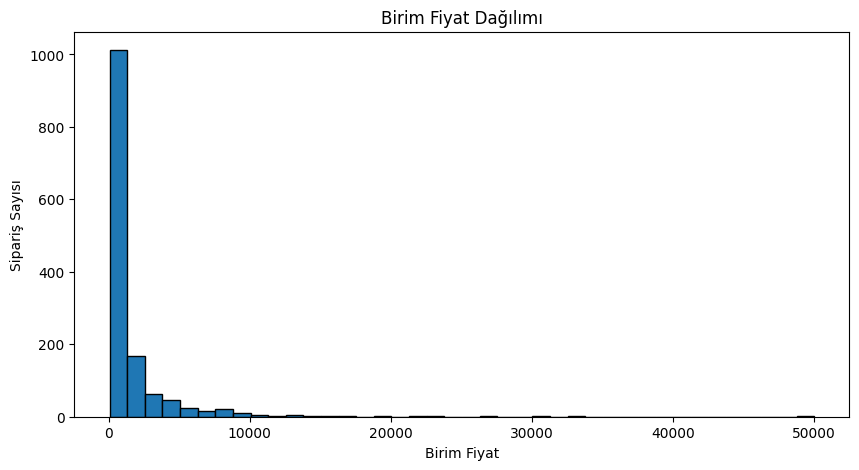

In [50]:
plt.figure(figsize=(10, 5))

plt.hist(
    gecerli_fiyatlar,
    bins=40,
    edgecolor="black"
)

plt.title("Birim Fiyat Dağılımı")
plt.xlabel("Birim Fiyat")
plt.ylabel("Sipariş Sayısı")

plt.show()

In [51]:
fiyat_yuzde_99 = (
    gecerli_fiyatlar
    .quantile(0.99)
)

print(
    "Fiyatların %99'unun altında kaldığı değer:",
    round(fiyat_yuzde_99, 2)
)

Fiyatların %99'unun altında kaldığı değer: 14218.67


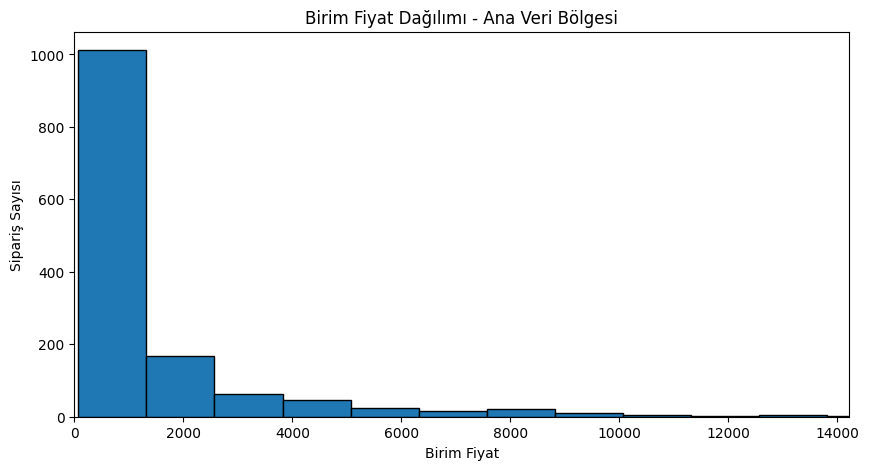

In [52]:
plt.figure(figsize=(10, 5))

plt.hist(
    gecerli_fiyatlar,
    bins=40,
    edgecolor="black"
)

plt.xlim(
    0,
    fiyat_yuzde_99
)

plt.title(
    "Birim Fiyat Dağılımı - Ana Veri Bölgesi"
)

plt.xlabel("Birim Fiyat")
plt.ylabel("Sipariş Sayısı")

plt.show()

ana veri bölgesi olarak gösterilmiştir buradaki problemimize göre karar alınmıştır elinizdeki veriler eğer gerçekten böyle satışlarında olabileceği veriler ise kullanbilirsiniz.

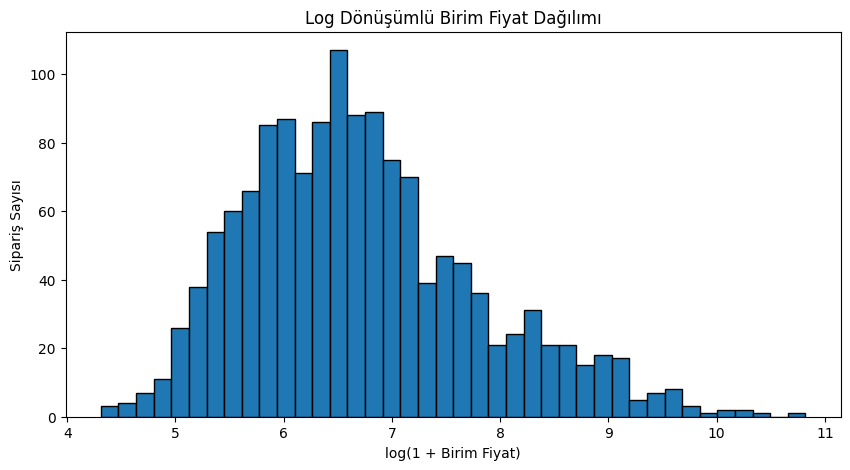

In [53]:
log_fiyatlar = np.log1p(
    gecerli_fiyatlar
)

plt.figure(figsize=(10, 5))

plt.hist(
    log_fiyatlar,
    bins=40,
    edgecolor="black"
)

plt.title(
    "Log Dönüşümlü Birim Fiyat Dağılımı"
)

plt.xlabel("log(1 + Birim Fiyat)")
plt.ylabel("Sipariş Sayısı")

plt.show()

Bu kod fiyatları logaritmik ölçeğe çeviriyor. Böylece dağılım daha dengeli görünüyor, uç değerler grafiği bozmaz ve istatistiksel analizler daha sağlıklı yapılabiliyor.

In [54]:
def iqr_ile_aykiri_deger_bul(
    dataframe,
    sutun_adi
):
    seri = (
        dataframe[sutun_adi]
        .dropna()
    )

    q1 = seri.quantile(0.25)
    q3 = seri.quantile(0.75)

    iqr = q3 - q1

    alt_sinir = q1 - 1.5 * iqr
    ust_sinir = q3 + 1.5 * iqr

    aykirilar = dataframe[
        (dataframe[sutun_adi] < alt_sinir) |
        (dataframe[sutun_adi] > ust_sinir)
    ]

    return (
        alt_sinir,
        ust_sinir,
        aykirilar
    )

In [55]:
alt_sinir, ust_sinir, fiyat_aykirilari = (
    iqr_ile_aykiri_deger_bul(
        df_analiz,
        "birim_fiyat"
    )
)

print(
    "IQR alt sınırı:",
    round(alt_sinir, 2)
)

print(
    "IQR üst sınırı:",
    round(ust_sinir, 2)
)

print(
    "Aykırı değer sayısı:",
    len(fiyat_aykirilari)
)

IQR alt sınırı: -1304.76
IQR üst sınırı: 3163.61
Aykırı değer sayısı: 176


belirli bir fiyat kesinlikle negatif değer alamaz ama unutmayın ki IQR bize sınırlarımızı belirler kesinlikle olması gereken mantıksal değer sınırları değildir

In [56]:
kategorik_sutunlar = [
    "sehir",
    "kategori",
    "kampanya",
    "odeme_yontemi",
    "cihaz",
    "iade_edildi"
]

for sutun in kategorik_sutunlar:
    print(f"\n--- {sutun} ---")

    print(
        df_analiz[sutun]
        .value_counts(
            dropna=False
        )
    )


--- sehir ---
sehir
İzmir       377
İstanbul    310
Ankara      300
Bursa       157
Elazığ      138
Malatya     110
Name: count, dtype: int64

--- kategori ---
kategori
Giyim         339
Elektronik    251
Ev & Yaşam    243
Kitap         200
Spor          181
Kozmetik      178
Name: count, dtype: int64

--- kampanya ---
kampanya
Yok                581
Sepette İndirim    294
Hafta Sonu         274
Yeni Üye           125
Özel Gün           118
Name: count, dtype: int64

--- odeme_yontemi ---
odeme_yontemi
Kredi Kartı     748
Banka Kartı     304
Havale/EFT      206
Kapıda Ödeme    120
NaN              14
Name: count, dtype: int64

--- cihaz ---
cihaz
Mobil       840
Masaüstü    430
Tablet      122
Name: count, dtype: int64

--- iade_edildi ---
iade_edildi
Hayır    1235
Evet      157
Name: count, dtype: int64


In [57]:
for sutun in kategorik_sutunlar:
    print(f"\n--- {sutun} yüzdeleri ---")

    print(
        df_analiz[sutun]
        .value_counts(
            normalize=True,
            dropna=False
        )
        .mul(100)
        .round(2)
    )


--- sehir yüzdeleri ---
sehir
İzmir       27.08
İstanbul    22.27
Ankara      21.55
Bursa       11.28
Elazığ       9.91
Malatya      7.90
Name: proportion, dtype: float64

--- kategori yüzdeleri ---
kategori
Giyim         24.35
Elektronik    18.03
Ev & Yaşam    17.46
Kitap         14.37
Spor          13.00
Kozmetik      12.79
Name: proportion, dtype: float64

--- kampanya yüzdeleri ---
kampanya
Yok                41.74
Sepette İndirim    21.12
Hafta Sonu         19.68
Yeni Üye            8.98
Özel Gün            8.48
Name: proportion, dtype: float64

--- odeme_yontemi yüzdeleri ---
odeme_yontemi
Kredi Kartı     53.74
Banka Kartı     21.84
Havale/EFT      14.80
Kapıda Ödeme     8.62
NaN              1.01
Name: proportion, dtype: float64

--- cihaz yüzdeleri ---
cihaz
Mobil       60.34
Masaüstü    30.89
Tablet       8.76
Name: proportion, dtype: float64

--- iade_edildi yüzdeleri ---
iade_edildi
Hayır    88.72
Evet     11.28
Name: proportion, dtype: float64


In [58]:
kategori_ozeti = (
    df_analiz
    .groupby("kategori")
    .agg(
        siparis_sayisi=(
            "siparis_id",
            "nunique"
        ),

        medyan_birim_fiyat=(
            "birim_fiyat",
            "median"
        ),

        ortalama_siparis_tutari=(
            "siparis_tutari",
            "mean"
        ),

        iade_orani=(
            "iade_edildi",
            lambda seri:
                (seri == "Evet").mean() * 100
        ),

        ortalama_memnuniyet=(
            "memnuniyet_puani",
            "mean"
        )
    )
    .round(2)
    .sort_values(
        "siparis_sayisi",
        ascending=False
    )
)

kategori_ozeti

,siparis_sayisi,medyan_birim_fiyat,ortalama_siparis_tutari,iade_orani,ortalama_memnuniyet
kategori,,,,,
Giyim,339,634.45,1384.92,19.76,3.97
Elektronik,251,4220.82,9960.20,8.76,4.06
Ev & Yaşam,243,932.92,1889.25,11.93,4.03
Kitap,200,226.94,406.25,3.00,4.16
Spor,181,883.96,1870.42,11.05,4.08
Kozmetik,178,390.10,796.96,7.30,4.18


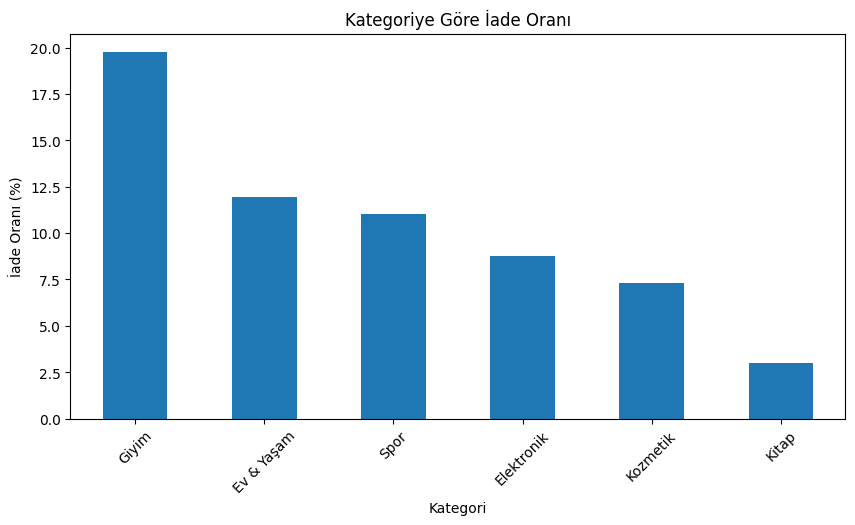

In [59]:
kategori_iade_orani = (
    kategori_ozeti["iade_orani"]
    .sort_values(
        ascending=False
    )
)

plt.figure(figsize=(10, 5))

kategori_iade_orani.plot(
    kind="bar"
)

plt.title(
    "Kategoriye Göre İade Oranı"
)

plt.xlabel("Kategori")
plt.ylabel("İade Oranı (%)")

plt.xticks(rotation=45)

plt.show()

In [62]:
df_analiz["kargo_grubu"] = pd.cut(
    df_analiz["kargo_gunu"],
    bins=[
        -1,
        2,
        4,
        7,
        np.inf
    ],
    labels=[
        "0-2 gün",
        "3-4 gün",
        "5-7 gün",
        "8+ gün"
    ]
)
kargo_ozeti = (
    df_analiz
    .groupby(
        "kargo_grubu",
        observed=False
    )
    .agg(
        siparis_sayisi=(
            "siparis_id",
            "count"
        ),

        ortalama_memnuniyet=(
            "memnuniyet_puani",
            "mean"
        ),

        iade_orani=(
            "iade_edildi",
            lambda seri:
                (seri == "Evet").mean() * 100
        )
    )
    .round(2)
)

kargo_ozeti

,siparis_sayisi,ortalama_memnuniyet,iade_orani
kargo_grubu,,,
0-2 gün,476,4.17,11.13
3-4 gün,546,4.16,10.44
5-7 gün,285,3.94,11.23
8+ gün,68,3.21,19.12


In [63]:
kampanya_ozeti = (
    df_analiz
    .groupby("kampanya")
    .agg(
        siparis_sayisi=(
            "siparis_id",
            "count"
        ),

        ortalama_indirim=(
            "indirim_orani",
            "mean"
        ),

        ortalama_siparis_tutari=(
            "siparis_tutari",
            "mean"
        ),

        iade_orani=(
            "iade_edildi",
            lambda seri:
                (seri == "Evet").mean() * 100
        )
    )
    .round(2)
    .sort_values(
        "siparis_sayisi",
        ascending=False
    )
)

kampanya_ozeti

,siparis_sayisi,ortalama_indirim,ortalama_siparis_tutari,iade_orani
kampanya,,,,
Yok,581,0.01,2850.29,11.19
Sepette İndirim,294,0.16,3211.44,10.54
Hafta Sonu,274,0.09,2442.49,10.95
Yeni Üye,125,0.13,4275.37,10.40
Özel Gün,118,0.22,1579.65,15.25


In [64]:
kampanya_kategori_tablosu = pd.crosstab(
    df_analiz["kampanya"],
    df_analiz["kategori"],
    normalize="index"
) * 100

kampanya_kategori_tablosu.round(2)

kategori,Elektronik,Ev & Yaşam,Giyim,Kitap,Kozmetik,Spor
kampanya,,,,,,
Hafta Sonu,17.88,18.25,22.99,13.50,15.69,11.68
Sepette İndirim,16.67,20.07,24.83,15.31,10.54,12.59
Yeni Üye,22.40,14.40,20.80,10.40,14.40,17.60
Yok,18.42,16.87,25.65,15.15,11.88,12.05
Özel Gün,15.25,15.25,23.73,14.41,14.41,16.95


% lik oran olarak verilmiştir

In [67]:
df_finans["ay"] = (
    df_finans["siparis_tarihi_dt"]
    .dt
    .to_period("M")
    .astype(str)
)
aylik_ozet = (
    df_finans
    .groupby("ay")
    .agg(
        siparis_sayisi=(
            "siparis_id",
            "nunique"
        ),

        toplam_ciro=(
            "siparis_tutari",
            "sum"
        ),

        ortalama_sepet=(
            "siparis_tutari",
            "mean"
        ),

        iade_orani=(
            "iade_edildi",
            lambda seri:
                (seri == "Evet").mean() * 100
        )
    )
    .round(2)
)

aylik_ozet

,siparis_sayisi,toplam_ciro,ortalama_sepet,iade_orani
ay,,,,
2025-01,111,321119.85,2892.97,9.01
2025-02,87,235926.96,2711.80,14.94
2025-03,115,308354.36,2681.34,6.09
2025-04,92,299433.53,3254.71,15.22
2025-05,119,354606.74,2979.89,7.56
2025-06,103,201007.91,1951.53,10.68
2025-07,115,326376.85,2838.06,11.30
2025-08,98,315576.87,3220.17,15.31
2025-09,102,273863.32,2684.93,11.76


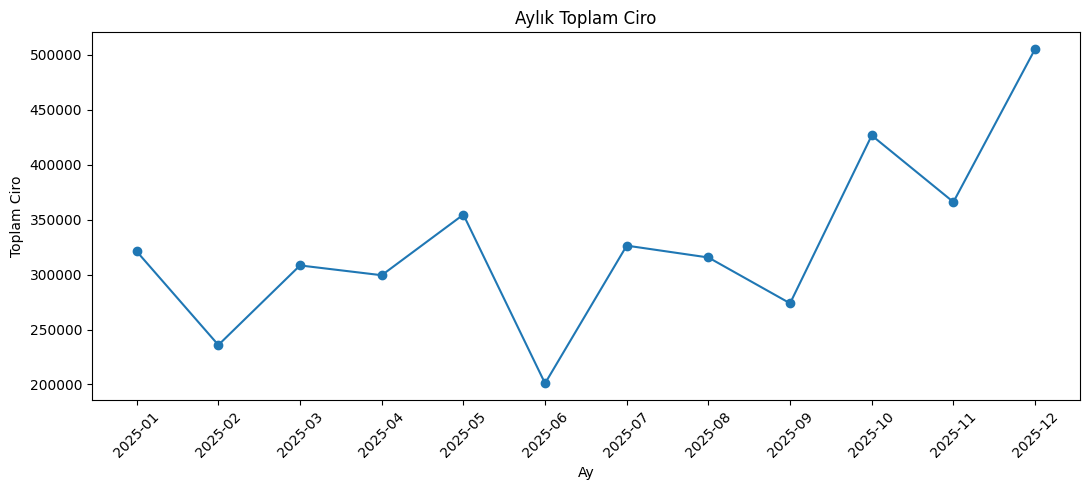

In [68]:
plt.figure(figsize=(11, 5))

plt.plot(
    aylik_ozet.index,
    aylik_ozet["toplam_ciro"],
    marker="o"
)

plt.title("Aylık Toplam Ciro")
plt.xlabel("Ay")
plt.ylabel("Toplam Ciro")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [69]:
hafta_sonu_ozeti = (
    df_analiz
    .groupby("hafta_sonu_mu")
    .agg(
        siparis_sayisi=(
            "siparis_id",
            "count"
        ),

        ortalama_tutar=(
            "siparis_tutari",
            "mean"
        ),

        iade_orani=(
            "iade_edildi",
            lambda seri:
                (seri == "Evet").mean() * 100
        )
    )
    .round(2)
)

hafta_sonu_ozeti

,siparis_sayisi,ortalama_tutar,iade_orani
hafta_sonu_mu,,,
False,1008,2976.02,11.01
True,384,2579.21,11.98


In [70]:
analiz_tarihi = (
    df_analiz["siparis_tarihi_dt"]
    .max()
    + pd.Timedelta(days=1)
)

print(
    "Analiz tarihi:",
    analiz_tarihi
)

Analiz tarihi: 2026-01-01 00:00:00


verimizin başlangıi tarihidir veri setinde sıralı şekilde bulunmuyordu

In [71]:
musteri_ozeti = (
    df_analiz
    .groupby("musteri_id")
    .agg(
        son_siparis_tarihi=(
            "siparis_tarihi_dt",
            "max"
        ),

        siparis_sayisi=(
            "siparis_id",
            "nunique"
        ),

        toplam_harcama=(
            "siparis_tutari",
            "sum"
        ),

        ortalama_sepet=(
            "siparis_tutari",
            "mean"
        ),

        iade_sayisi=(
            "iade_edildi",
            lambda seri:
                (seri == "Evet").sum()
        )
    )
)

In [72]:
musteri_ozeti[
    "son_siparisten_gecen_gun"
] = (
    analiz_tarihi
    - musteri_ozeti[
        "son_siparis_tarihi"
    ]
).dt.days

In [73]:
musteri_ozeti.head()

,son_siparis_tarihi,siparis_sayisi,toplam_harcama,ortalama_sepet,iade_sayisi,son_siparisten_gecen_gun
musteri_id,,,,,,
M0001,2025-07-15,3,1187.36,395.786667,1,170
M0002,2025-12-13,4,6377.57,1594.392500,0,19
M0003,2025-12-29,2,29304.03,14652.015000,0,3
M0004,2025-03-18,1,617.82,617.820000,0,289
M0005,2025-08-19,2,3808.95,1904.475000,0,135


In [74]:
musteri_ozeti[
    [
        "son_siparisten_gecen_gun",
        "siparis_sayisi",
        "toplam_harcama"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
son_siparisten_gecen_gun,283.0,97.957597,93.518032,1.00,24.00,63.0,153.5,362.00
siparis_sayisi,283.0,4.918728,14.273560,1.00,2.00,3.0,5.0,235.00
toplam_harcama,283.0,14099.787173,42047.018628,113.87,2237.47,6337.9,13950.3,665294.16


toplam harcamaya dikkat edin ve standart sapma da çok yüksek ve min ile max arasındaki değer de çok fazla

In [75]:
en_cok_harcayan_musteriler = (
    musteri_ozeti
    .sort_values(
        "toplam_harcama",
        ascending=False
    )
    .head(10)
)

en_cok_harcayan_musteriler

,son_siparis_tarihi,siparis_sayisi,toplam_harcama,ortalama_sepet,iade_sayisi,son_siparisten_gecen_gun
musteri_id,,,,,,
M0309,2025-12-31,235,665294.16,2831.038979,28,1
M0316,2025-12-04,18,106900.23,5938.901667,3,28
M0134,2025-12-19,9,99173.92,11019.324444,1,13
M0298,2025-12-30,9,85593.12,9510.346667,2,2
M0306,2025-12-13,30,71917.28,2397.242667,2,19
M0312,2025-11-19,12,68247.70,5687.308333,2,43
M0252,2025-10-15,8,63669.09,7958.636250,1,78
M0245,2025-12-29,18,61852.89,3436.271667,1,3
M0181,2025-12-31,3,58627.93,19542.643333,0,1


In [76]:
en_sik_siparis_verenler = (
    musteri_ozeti
    .sort_values(
        "siparis_sayisi",
        ascending=False
    )
    .head(10)
)

en_sik_siparis_verenler

,son_siparis_tarihi,siparis_sayisi,toplam_harcama,ortalama_sepet,iade_sayisi,son_siparisten_gecen_gun
musteri_id,,,,,,
M0309,2025-12-31,235,665294.16,2831.038979,28,1
M0306,2025-12-13,30,71917.28,2397.242667,2,19
M0305,2025-12-27,25,54879.35,2195.174000,6,5
M0191,2025-12-10,20,51355.55,2567.777500,2,22
M0220,2025-12-19,19,19597.11,1031.426842,0,13
M0316,2025-12-04,18,106900.23,5938.901667,3,28
M0119,2025-10-08,18,55615.12,3089.728889,3,85
M0245,2025-12-29,18,61852.89,3436.271667,1,3
M0024,2025-11-28,17,25931.49,1525.381765,1,34


In [77]:
korelasyon_sutunlari = [
    "birim_fiyat",
    "adet",
    "indirim_orani",
    "kargo_gunu",
    "memnuniyet_puani",
    "siparis_tutari"
]

In [79]:
pearson_korelasyon = (
    df_analiz[
        korelasyon_sutunlari
    ]
    .corr(
        method="pearson"
    )
)

pearson_korelasyon

,birim_fiyat,adet,indirim_orani,kargo_gunu,memnuniyet_puani,siparis_tutari
birim_fiyat,1.000000,0.017242,0.006520,0.058410,0.001606,0.675883
adet,0.017242,1.000000,0.011863,-0.022302,-0.018501,0.293934
indirim_orani,0.006520,0.011863,1.000000,-0.030029,-0.051999,-0.025576
kargo_gunu,0.058410,-0.022302,-0.030029,1.000000,-0.177065,0.027780
memnuniyet_puani,0.001606,-0.018501,-0.051999,-0.177065,1.000000,-0.003101
siparis_tutari,0.675883,0.293934,-0.025576,0.027780,-0.003101,1.000000


In [80]:
spearman_korelasyon = (
    df_analiz[
        korelasyon_sutunlari
    ]
    .corr(
        method="spearman"
    )
)

spearman_korelasyon

,birim_fiyat,adet,indirim_orani,kargo_gunu,memnuniyet_puani,siparis_tutari
birim_fiyat,1.000000,0.002020,0.002565,0.060838,-0.007540,0.864500
adet,0.002020,1.000000,0.043411,-0.003089,-0.008523,0.457094
indirim_orani,0.002565,0.043411,1.000000,-0.033590,-0.050195,-0.054512
kargo_gunu,0.060838,-0.003089,-0.033590,1.000000,-0.145107,0.056980
memnuniyet_puani,-0.007540,-0.008523,-0.050195,-0.145107,1.000000,-0.010412
siparis_tutari,0.864500,0.457094,-0.054512,0.056980,-0.010412,1.000000


Pearson korelasyonu iki değişken arasındaki doğrusal (linear) ilişkiyi ölçerken, Spearman korelasyonu değişkenlerin sıralı (rank) değerleri üzerinden çalışır ve doğrusal olmasa bile monotonik ilişkileri yakalayabilir. Pearson daha hassas ama outlier’lara duyarlı, Spearman ise daha esnek ve uç değerlerden etkilenmez.

In [81]:
kargo_memnuniyet_korelasyonlari = pd.Series({
    "Pearson": (
        df_analiz[
            ["kargo_gunu", "memnuniyet_puani"]
        ]
        .corr(method="pearson")
        .iloc[0, 1]
    ),

    "Spearman": (
        df_analiz[
            ["kargo_gunu", "memnuniyet_puani"]
        ]
        .corr(method="spearman")
        .iloc[0, 1]
    )
})

kargo_memnuniyet_korelasyonlari.round(3)

,0
Pearson,-0.177
Spearman,-0.145


In [82]:
print("E-TİCARET EDA ÖZETİ")
print("-" * 50)

print(
    "Ham satır sayısı:",
    len(df)
)

print(
    "Analiz satır sayısı:",
    len(df_analiz)
)

print(
    "Benzersiz müşteri sayısı:",
    df_analiz["musteri_id"].nunique()
)

print(
    "Benzersiz sipariş sayısı:",
    df_analiz["siparis_id"].nunique()
)

print("\nEksik değerler:")
print(
    df_analiz
    .isna()
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

print("\nKategori özeti:")
display(kategori_ozeti)

print("\nAylık özet:")
display(aylik_ozet)

print("\nKargo özeti:")
display(kargo_ozeti)

E-TİCARET EDA ÖZETİ
--------------------------------------------------
Ham satır sayısı: 1410
Analiz satır sayısı: 1392
Benzersiz müşteri sayısı: 283
Benzersiz sipariş sayısı: 1392

Eksik değerler:
memnuniyet_puani           87
kargo_gunu                 17
kargo_grubu                17
odeme_yontemi              14
beklenen_siparis_tutari    10
tutar_farki                10
indirim_orani              10
siparis_tarihi              0
musteri_id                  0
siparis_id                  0
dtype: int64

Kategori özeti:


,siparis_sayisi,medyan_birim_fiyat,ortalama_siparis_tutari,iade_orani,ortalama_memnuniyet
kategori,,,,,
Giyim,339,634.45,1384.92,19.76,3.97
Elektronik,251,4220.82,9960.20,8.76,4.06
Ev & Yaşam,243,932.92,1889.25,11.93,4.03
Kitap,200,226.94,406.25,3.00,4.16
Spor,181,883.96,1870.42,11.05,4.08
Kozmetik,178,390.10,796.96,7.30,4.18



Aylık özet:


,siparis_sayisi,toplam_ciro,ortalama_sepet,iade_orani
ay,,,,
2025-01,111,321119.85,2892.97,9.01
2025-02,87,235926.96,2711.80,14.94
2025-03,115,308354.36,2681.34,6.09
2025-04,92,299433.53,3254.71,15.22
2025-05,119,354606.74,2979.89,7.56
2025-06,103,201007.91,1951.53,10.68
2025-07,115,326376.85,2838.06,11.30
2025-08,98,315576.87,3220.17,15.31
2025-09,102,273863.32,2684.93,11.76



Kargo özeti:


,siparis_sayisi,ortalama_memnuniyet,iade_orani
kargo_grubu,,,
0-2 gün,476,4.17,11.13
3-4 gün,546,4.16,10.44
5-7 gün,285,3.94,11.23
8+ gün,68,3.21,19.12
